In [1]:
import pandas as pd
import numpy as np
import warnings
import os  # Added for Kaggle path handling

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

def process_biforge_dataset(input_csv, weights_csv=None, output_csv='BIFORGE_StageB_Ready.csv'):
    print("Loading dataset...")
    df = pd.read_csv(input_csv)

    # --- 1. CLEANING & PREPARATION ---
    print("Cleaning Region IDs and Dates...")
    # Extract RegionID from system:index (e.g., '10_000000...00a2' -> '000000...00a2')
    df['RegionID'] = df['system:index'].apply(lambda x: str(x).split('_')[-1])
    df['Date'] = pd.to_datetime(df['Date'])

    # Define the core feature columns
    feature_cols = ['NDVI', 'EVI', 'Temp_K', 'Precip_m', 'Solar_J']

    # --- 2. CALCULATE CONFIDENCE SCORE (Before Interpolation) ---
    print("Calculating Global Confidence Scores...")
    # Count unique regions per date. Expected regions = 50.
    regions_per_date = df.groupby('Date')['RegionID'].nunique()
    expected_regions = 50
    confidence = (regions_per_date / expected_regions).rename('Confidence')

    # --- 3. STRICT 10-DAY GRID REGULARIZATION ---
    print("forcing strict 10-day grid...")
    min_date = df['Date'].min()
    max_date = df['Date'].max()
    grid_dates = pd.date_range(start=min_date, end=max_date, freq='10D')
    unique_regions = df['RegionID'].unique()

    # Create MultiIndex (Region x Date)
    idx = pd.MultiIndex.from_product([unique_regions, grid_dates], names=['RegionID', 'Date'])
    df_grid = pd.DataFrame(index=idx).reset_index()

    # Merge original data onto the grid
    df_merged = pd.merge(df_grid, df, on=['RegionID', 'Date'], how='left')

    # Merge Confidence Score (broadcast to all regions for that date)
    df_merged = pd.merge(df_merged, confidence, on='Date', how='left')
    # If a date has NO data (Confidence is NaN), it means Confidence is 0
    df_merged['Confidence'] = df_merged['Confidence'].fillna(0.0)

    # Drop old index column
    if 'system:index' in df_merged.columns:
        df_merged.drop(columns=['system:index'], inplace=True)

    # --- 4. ROBUST INTERPOLATION (No Forward Peeking) ---
    print("Interpolating gaps (Forward Fill + Climatology Fallback)...")
    df_merged = df_merged.sort_values(['RegionID', 'Date'])

    # A. Forward Fill (Limit 3 dekads / 30 days)
    # Group by Region to ensure we don't carry data across regions
    df_merged[feature_cols] = df_merged.groupby('RegionID')[feature_cols].ffill(limit=3)

    # B. Climatology Fallback (Expanding Window Mean per Dekad)
    # Calculate Dekad Index (1-36)
    df_merged['DOY'] = df_merged['Date'].dt.dayofyear
    df_merged['Dekad_Index'] = ((df_merged['DOY'] - 1) // 10 + 1).clip(upper=36)

    # For each feature, fill remaining NaNs with the Expanding Mean of that (Region, Dekad)
    for col in feature_cols:
        # Calculate expanding mean grouped by Region and Dekad Index
        # sort_values ensures we process in time order, so this is strictly past data
        # Note: We use the existing values to compute the mean, then use that mean to fill NaNs
        # We use a temporary groupby object
        grouper = df_merged.groupby(['RegionID', 'Dekad_Index'])[col]

        # Calculate expanding mean (ignoring NaNs in calculation)
        expanding_mean = grouper.transform(lambda x: x.expanding().mean())

        # Fill NaNs
        df_merged[col] = df_merged[col].fillna(expanding_mean)

    # Drop rows that are still NaN (start of history where no expanding mean exists)
    df_clean = df_merged.dropna(subset=feature_cols).copy()

    # --- 5. AREA WEIGHTING ---
    if weights_csv:
        print(f"Merging Area Weights from {weights_csv}...")
        try:
            weights = pd.read_csv(weights_csv)
            # Ensure RegionID format matches
            # If weights file has 'system:index' instead of 'RegionID', clean it
            if 'RegionID' not in weights.columns and 'system:index' in weights.columns:
                 weights['RegionID'] = weights['system:index'].apply(lambda x: str(x).split('_')[-1])
            elif 'RegionID' in weights.columns:
                 weights['RegionID'] = weights['RegionID'].astype(str)

            # Merge wheat_pixels
            df_clean = pd.merge(df_clean, weights[['RegionID', 'wheat_pixels']], on='RegionID', how='left')
        except Exception as e:
            print(f"Warning: Could not merge weights ({e}). Skipping...")
    else:
        print("Warning: No weights file provided. Skipping Area Weighting.")

    # --- 6. FEATURE ENGINEERING ---
    print("Calculating Statistics (Z-Scores, Rolling Windows)...")

    # A. Expanding Window Z-Scores
    for col in feature_cols:
        grouper = df_clean.groupby(['RegionID', 'Dekad_Index'])[col]
        exp_mean = grouper.transform(lambda x: x.expanding().mean())
        exp_std = grouper.transform(lambda x: x.expanding().std())

        # Avoid division by zero
        exp_std = exp_std.replace(0, 1)

        df_clean[f'{col}_Z'] = (df_clean[col] - exp_mean) / exp_std

    # B. Rolling Window Statistics
    # Windows: 1M (3), 3M (9), 6M (18), 1Y (36)
    windows = {'1M': 3, '3M': 9, '6M': 18, '1Y': 36}

    # We group by RegionID once
    grouped_region = df_clean.groupby('RegionID')

    for col in feature_cols:
        for w_name, w_size in windows.items():
            # Basic Rolling Stats
            df_clean[f'{col}_RollMin_{w_name}'] = grouped_region[col].transform(lambda x: x.rolling(w_size).min())
            df_clean[f'{col}_RollMax_{w_name}'] = grouped_region[col].transform(lambda x: x.rolling(w_size).max())
            df_clean[f'{col}_RollStd_{w_name}'] = grouped_region[col].transform(lambda x: x.rolling(w_size).std())

            # Change: F(t) - F(t-h)
            change_col = grouped_region[col].transform(lambda x: x.diff(w_size))
            df_clean[f'{col}_Change_{w_name}'] = change_col

            # Slope: Change / h
            df_clean[f'{col}_Slope_{w_name}'] = change_col / w_size

    # Drop rows with NaNs created by rolling windows/z-scores (start of series)
    # Using Z-score columns as proxy for valid history start
    z_cols = [f'{c}_Z' for c in feature_cols]
    df_final = df_clean.dropna(subset=z_cols)

    # Save
    print(f"Saving final dataset to {output_csv}...")
    df_final.to_csv(output_csv, index=False)
    print("Done! Pipeline Complete.")
    return df_final
# --- EXECUTION ---
if __name__ == "__main__":
    # --- KAGGLE-SPECIFIC TWEAK ---
    # Since you have the exact path, we can use it directly.
    
    process_biforge_dataset(
        input_csv='/kaggle/input/bioforgemergedfinal/BIFORGE_Dataset_Final_Merged.csv',  # <--- YOUR PATH HERE
        weights_csv=None, # Set to your weights file path if you have one, or keep None
        output_csv='BIFORGE_StageB_Ready.csv'
    )

Loading dataset...
Cleaning Region IDs and Dates...
Calculating Global Confidence Scores...
forcing strict 10-day grid...
Interpolating gaps (Forward Fill + Climatology Fallback)...
Calculating Statistics (Z-Scores, Rolling Windows)...
Saving final dataset to BIFORGE_StageB_Ready.csv...
Done! Pipeline Complete.


In [3]:

df_check = pd.read_csv('BIFORGE_StageB_Ready.csv')

print(len(df_check.columns))


115

In [5]:
df_check.columns.tolist()

['RegionID',
 'Date',
 'NDVI',
 'EVI',
 'Temp_K',
 'Precip_m',
 'Solar_J',
 'Confidence',
 'DOY',
 'Dekad_Index',
 'NDVI_Z',
 'EVI_Z',
 'Temp_K_Z',
 'Precip_m_Z',
 'Solar_J_Z',
 'NDVI_RollMin_1M',
 'NDVI_RollMax_1M',
 'NDVI_RollStd_1M',
 'NDVI_Change_1M',
 'NDVI_Slope_1M',
 'NDVI_RollMin_3M',
 'NDVI_RollMax_3M',
 'NDVI_RollStd_3M',
 'NDVI_Change_3M',
 'NDVI_Slope_3M',
 'NDVI_RollMin_6M',
 'NDVI_RollMax_6M',
 'NDVI_RollStd_6M',
 'NDVI_Change_6M',
 'NDVI_Slope_6M',
 'NDVI_RollMin_1Y',
 'NDVI_RollMax_1Y',
 'NDVI_RollStd_1Y',
 'NDVI_Change_1Y',
 'NDVI_Slope_1Y',
 'EVI_RollMin_1M',
 'EVI_RollMax_1M',
 'EVI_RollStd_1M',
 'EVI_Change_1M',
 'EVI_Slope_1M',
 'EVI_RollMin_3M',
 'EVI_RollMax_3M',
 'EVI_RollStd_3M',
 'EVI_Change_3M',
 'EVI_Slope_3M',
 'EVI_RollMin_6M',
 'EVI_RollMax_6M',
 'EVI_RollStd_6M',
 'EVI_Change_6M',
 'EVI_Slope_6M',
 'EVI_RollMin_1Y',
 'EVI_RollMax_1Y',
 'EVI_RollStd_1Y',
 'EVI_Change_1Y',
 'EVI_Slope_1Y',
 'Temp_K_RollMin_1M',
 'Temp_K_RollMax_1M',
 'Temp_K_RollStd_1M',
 

In [35]:
df.head

<bound method NDFrame.head of                    RegionID        Date      NDVI       EVI      Temp_K  \
0      00000000000000000079  1985-05-15  0.574228  0.395681  292.890965   
1      00000000000000000079  1985-05-25  0.574228  0.395681  292.890965   
2      00000000000000000079  1985-06-04  0.574228  0.395681  292.890965   
3      00000000000000000079  1985-06-14  0.607676  0.509073  293.801895   
4      00000000000000000079  1985-06-24  0.309857  1.298231  298.285278   
...                     ...         ...       ...       ...         ...   
68816  00000000000000000afa  2024-11-16  0.227122  0.143811  277.309867   
68817  00000000000000000afa  2024-11-26  0.226547  0.143397  274.686770   
68818  00000000000000000afa  2024-12-06  0.216134  0.137955  275.738280   
68819  00000000000000000afa  2024-12-16  0.214296  0.138460  277.137946   
68820  00000000000000000afa  2024-12-26  0.214296  0.138460  277.137946   

       Precip_m       Solar_J  Confidence  DOY  Dekad_Index  ...  \
0

In [32]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import pandas as pd
import numpy as np
import os
INPUT_FILE = '/kaggle/working/BIFORGE_StageB_Ready.csv'

OUTPUT_FILE = 'BIFORGE_StageB1_Latents.csv'
LATENT_DIM = 16
EPOCHS = 50
BATCH_SIZE = 64
LR = 0.001

df = pd.read_csv(INPUT_FILE)

df.head()

feature_cols = [c for c in df.columns if ('_Z' in c) or ('_Roll' in c) or ('_Change' in c) or ('_Slope' in c)]
feature_cols += ['Confidence']
feature_cols += ['NDVI']
feature_cols += ['Temp_K']
feature_cols += ['Precip_m']
feature_cols += ['Solar_J']
print(len(feature_cols))

def temporal_scale_global_correct(df, feature_cols):
    
    temp_df = df[['Date', 'RegionID'] + feature_cols].copy()
    temp_df['Date'] = pd.to_datetime(temp_df['Date'])
    
    # FIXED: Sort by DATE first, then RegionID
    temp_df = temp_df.sort_values(['Date', 'RegionID']).reset_index(drop=True)
    temp_df['original_index'] = df.index
    
    scaled_cols = []
    
    for col in feature_cols:

        exp_mean = temp_df[col].expanding(min_periods=1).mean()
        exp_std = temp_df[col].expanding(min_periods=1).std()
        exp_mean_past = exp_mean.shift(1)
        exp_std_past = exp_std.shift(1)
        exp_mean_past.iloc[0] = temp_df[col].iloc[0]  
        exp_std_past.iloc[0] = 1.0
        exp_std_past = exp_std_past.fillna(1.0)
        exp_std_past = exp_std_past.replace(0, 1.0)
        exp_std_past = exp_std_past.clip(lower=0.01)
        
        scaled_col = (temp_df[col] - exp_mean_past) / exp_std_past
        scaled_col.iloc[0] = 0.0
        
        #Clipping
        scaled_col = scaled_col.clip(-10, 10)

        
        scaled_col = scaled_col.fillna(0)
        
        scaled_cols.append(scaled_col.values)
    
    # Stack columns
    scaled_array = np.column_stack(scaled_cols)
    
    # Return to original order
    temp_df['sort_key'] = range(len(temp_df))
    reorder_map = temp_df.set_index('original_index')['sort_key'].to_dict()
    reorder_indices = [reorder_map[i] for i in df.index]

    return scaled_array[reorder_indices]


X_scaled = temporal_scale_global_correct(df, feature_cols)



110


In [33]:
len(X_scaled)

68821

In [30]:
X_scaled_df = pd.DataFrame(X_scaled)
print(X_scaled_df.head())

            0             1         2             3             4         5    \
0  0.000000e+00  0.000000e+00  0.000000  0.000000e+00  0.000000e+00  0.000000   
1 -3.330669e-16 -1.110223e-16 -1.414214 -5.551115e-16  2.220446e-16  0.062069   
2 -3.330669e-14  1.110223e-16  0.707107 -1.000000e+01  1.000000e+01 -0.120725   
3  0.000000e+00  0.000000e+00 -1.154701 -1.154701e+00 -5.773503e-01 -0.144184   
4 -3.330669e-14  1.110223e-14 -0.866025  8.660254e-01 -5.000000e-01 -7.434578   

        6          7          8         9    ...        96         97   \
0  0.000000   0.000000   0.000000  0.000000  ...   0.000000   0.000000   
1  0.081103   0.010990  -0.019034 -0.006345  ... -10.000000 -10.000000   
2 -0.395808  -1.004621   0.081350  0.036498  ...  -0.312090  -3.201464   
3  0.356925   1.137801  10.000000  9.039359  ...  -0.465335  -1.017288   
4  3.538353  10.000000  -2.822635 -2.822635  ...  -1.001235  -0.737144   

         98         99   100  101  102  103  104  105  
0   0.000000

In [37]:

# Convert to PyTorch Tensors
dataset = TensorDataset(torch.FloatTensor(X_scaled))
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

In [38]:
# ==========================================
#  DEFINING AUTOENCODER
# ==========================================
class DenoisingAutoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super(DenoisingAutoencoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, latent_dim),
            nn.Tanh()
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, input_dim)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return encoded, decoded

model = DenoisingAutoencoder(len(feature_cols), LATENT_DIM)
optimizer = optim.Adam(model.parameters(), lr=LR)
criterion = nn.MSELoss()

# ==========================================
# 3. TRAIN THE MODEL
# ==========================================
print("\nStarting Training...")
model.train()

best_loss = float('inf')
patience_counter = 0

for epoch in range(EPOCHS):
    total_loss = 0
    batch_count = 0
    
    for batch in dataloader:
        x_batch = batch[0]

        # Add Noise
        noise = torch.randn_like(x_batch) * 0.1
        x_noisy = x_batch + noise

        # Forward pass
        _, decoded = model(x_noisy)
        loss = criterion(decoded, x_batch)
        
        # NaN detection
        if torch.isnan(loss) or torch.isinf(loss):
            print(f"\nWARNING: NaN/Inf loss at epoch {epoch+1}, batch {batch_count}")
            print(f"Batch stats: min={x_batch.min():.3f}, max={x_batch.max():.3f}, mean={x_batch.mean():.3f}")
            print("Stopping training.")
            break

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()

        total_loss += loss.item()
        batch_count += 1
    
    # Check if we should stop
    if torch.isnan(loss) or torch.isinf(loss):
        print("Training terminated due to NaN.")
        break
    
    avg_loss = total_loss / batch_count
    
    # Track best loss
    if avg_loss < best_loss:
        best_loss = avg_loss
        patience_counter = 0
    else:
        patience_counter += 1

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {avg_loss:.4f} | Best: {best_loss:.4f}")

print(f"\nTraining complete. Best loss: {best_loss:.4f}")




Starting Training...
Epoch 10/50 | Loss: 0.1366 | Best: 0.1366
Epoch 20/50 | Loss: 0.1199 | Best: 0.1199
Epoch 30/50 | Loss: 0.1135 | Best: 0.1135
Epoch 40/50 | Loss: 0.1104 | Best: 0.1104
Epoch 50/50 | Loss: 0.1078 | Best: 0.1078

Training complete. Best loss: 0.1078


In [39]:
# ==========================================
# 4. EXPORT LATENT VECTORS
# ==========================================
print("\nGenerating Latent Features...")
model.eval()

with torch.no_grad():
    full_tensor = torch.FloatTensor(X_scaled)
    latents, _ = model(full_tensor)
    latents_np = latents.cpu().numpy()

# Validate latents
if np.isnan(latents_np).any():
    print("ERROR: NaN in latent vectors!")
    raise ValueError("Cannot export NaN latents")

print(f"Latent range: [{latents_np.min():.2f}, {latents_np.max():.2f}]")

# Create DataFrame
latent_cols = [f'Latent_{i}' for i in range(LATENT_DIM)]
df_latent = pd.DataFrame(latents_np, columns=latent_cols)

# Attach metadata
df_latent['RegionID'] = df['RegionID'].values
df_latent['Date'] = df['Date'].values
df_latent['Dekad_Index'] = df['Dekad_Index'].values

# Save
df_latent.to_csv(OUTPUT_FILE, index=False)



Generating Latent Features...
Latent range: [-0.86, 0.89]


In [40]:
import requests
import pandas as pd
import time

# ==========================================
# CONFIGURATION
# ==========================================
# PASTE YOUR API KEY HERE
API_KEY = 'CFFB3106-829C-3879-92FA-AF8A7CB0C88E'

# In Kaggle, files saved to the current directory appear in /kaggle/working/
OUTPUT_FILE = 'usda_yields.csv'

# The 5 States in your Wheat Belt
# FIPS State Codes: CO(08), KS(20), NE(31), OK(40), TX(48)
TARGET_STATES = ['CO', 'KS', 'NE', 'OK', 'TX']

# ==========================================
# 1. FETCH DATA FROM USDA NASS
# ==========================================
print("Fetching USDA Yield Data (1984-2024)...")

base_url = "http://quickstats.nass.usda.gov/api/api_GET"

params = {
    'key': API_KEY,
    'source_desc': 'SURVEY',
    'sector_desc': 'CROPS',
    'group_desc': 'FIELD CROPS',
    'commodity_desc': 'WHEAT',
    # We specifically want Winter Wheat yields
    'short_desc': 'WHEAT, WINTER - YIELD, MEASURED IN BU / ACRE',
    'domain_desc': 'TOTAL',
    'agg_level_desc': 'COUNTY',
    'year__GE': '1984',
    'format': 'JSON'
}

# We have to request state-by-state to avoid timeout/size limits
all_data = []

for state in TARGET_STATES:
    print(f"  -> Requesting {state}...")
    current_params = params.copy()
    current_params['state_alpha'] = state

    try:
        response = requests.get(base_url, params=current_params)
        data = response.json()

        if 'data' in data:
            all_data.extend(data['data'])
        else:
            print(f"     Warning: No data returned for {state}")

    except Exception as e:
        print(f"     Error fetching {state}: {e}")

    # Be polite to the API
    time.sleep(1)

print(f"Total Records Fetched: {len(all_data)}")

# ==========================================
# 2. CLEAN & FORMAT (CRITICAL STEP)
# ==========================================
if len(all_data) > 0:
    df = pd.DataFrame(all_data)

    print("Cleaning Data...")

    # 1. Construct FIPS Code (RegionID)
    # USDA gives 'state_ansi' (e.g., '20') and 'county_ansi' (e.g., '001')
    # We must combine them to get '20001' to match your GEE RegionIDs

    # Drop rows where ANSI codes are missing (sometimes happens for "OTHER COUNTIES")
    df = df.dropna(subset=['state_ansi', 'county_ansi'])

    # Ensure zero-padding (e.g., state 5 -> '05', county 1 -> '001')
    df['state_ansi'] = df['state_ansi'].astype(str).str.zfill(2)
    df['county_ansi'] = df['county_ansi'].astype(str).str.zfill(3)

    # Create RegionID
    df['RegionID'] = df['state_ansi'] + df['county_ansi']

    # 2. Clean Yield Values
    # Remove commas (e.g., "1,000") and convert to float
    df['Value'] = df['Value'].astype(str).str.replace(',', '').str.strip()
    # Coerce to numeric, drop errors
    df['Yield_Bushels'] = pd.to_numeric(df['Value'], errors='coerce')

    # 3. Select & Rename Columns
    final_df = df[['RegionID', 'year', 'Yield_Bushels']].copy()
    final_df.columns = ['RegionID', 'Year', 'Yield']

    # 4. Remove NaNs
    final_df = final_df.dropna()

    # 5. Sort
    final_df = final_df.sort_values(['RegionID', 'Year'])

    # ==========================================
    # 3. SAVE
    # ==========================================
    final_df.to_csv(OUTPUT_FILE, index=False)
    print(f"Success! Saved {len(final_df)} yield records to {OUTPUT_FILE}")
    print("First 5 rows:")
    print(final_df.head())

else:
    print("FAILED. No data collected. Check your API Key.")

Fetching USDA Yield Data (1984-2024)...
  -> Requesting CO...
  -> Requesting KS...
  -> Requesting NE...
  -> Requesting OK...
  -> Requesting TX...
Total Records Fetched: 16456
Cleaning Data...
Success! Saved 16456 yield records to usda_yields.csv
First 5 rows:
    RegionID  Year  Yield
8      08000  2004   30.5
91     08000  2004   32.0
311    08000  2004   26.5
727    08000  2004   30.0
955    08000  2004   80.0


In [41]:
# Install geemap if not already present
!pip install geemap

import ee
import geemap
import pandas as pd

# 1. Initialize
try:
    ee.Authenticate()
    ee.Initialize(project='wheat-project-483813')
    print("Authenticated and Connected.")
except Exception as e:
    print(f"Connection failed: {e}")
    # Fallback for cached credentials
    ee.Initialize(project='wheat-project-483813')

# ==========================================
# REPLICATE YOUR REGION SELECTION LOGIC
# ==========================================
print("Calculating Area Weights for the Top 50 Regions...")

# 1. Define Sources (Matches your main script exactly)
states = ee.FeatureCollection('TIGER/2018/States')\
    .filter(ee.Filter.inList('NAME', ['Kansas', 'Oklahoma', 'Texas', 'Nebraska', 'Colorado']))
cdl = ee.Image('USDA/NASS/CDL/2020').select('cropland')
winter_wheat = cdl.eq(24) # Class 24 is Winter Wheat
counties = ee.FeatureCollection('TIGER/2018/Counties').filterBounds(states)

# 2. Calculate Wheat Pixels per County
def get_wheat_sum(feature):
    sum_wheat = winter_wheat.reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=feature.geometry(),
        scale=5000,
        maxPixels=1e9
    )
    # --- CRITICAL FIX IS HERE ---
    # We add 'GEOID' which is the FIPS code (e.g., 20191)
    return feature.set({
        'wheat_pixels': sum_wheat.get('cropland'),
        'RegionID': feature.id(),    # The GEE Hash (matches your Latents)
        'NAME': feature.get('NAME'), # The County Name
        'GEOID': feature.get('GEOID') # The FIPS Code (matches USDA)
    })

# 3. Filter Top 50 (Same logic as main script)
top_counties = counties.map(get_wheat_sum).sort('wheat_pixels', False).limit(50)

# ==========================================
# EXPORT 1: TO GOOGLE DRIVE (Original Method)
# ==========================================
task = ee.batch.Export.table.toDrive(
    collection=top_counties,
    description='BIFORGE_Area_Weights_Fixed', # Changed name to avoid confusion
    folder='BIFORGE_Data',
    fileFormat='CSV',
    # --- CRITICAL FIX IS HERE ---
    # Added 'GEOID' to the list of columns to save
    selectors=['RegionID', 'GEOID', 'wheat_pixels', 'NAME']
)

task.start()
print("-> Export Task Started: BIFORGE_Area_Weights_Fixed (to Google Drive)")

# ==========================================
# EXPORT 2: TO KAGGLE LOCAL DIR (Added for Immediate Use)
# ==========================================
print("-> Saving local copy for immediate use in Kaggle...")
try:
    # Use robust .getInfo() method to avoid geemap dependency issues
    data_json = top_counties.getInfo()
    
    # Extract the 'properties' from each feature
    data_list = [feature['properties'] for feature in data_json['features']]
    
    # Create DataFrame
    df_local = pd.DataFrame(data_list)
    
    # Ensure correct columns are selected
    df_local = df_local[['RegionID', 'GEOID', 'wheat_pixels', 'NAME']]
    
    # Save to the Kaggle working directory
    df_local.to_csv('BIFORGE_Area_Weights_Fixed.csv', index=False)
    print("-> Success! 'BIFORGE_Area_Weights_Fixed.csv' saved to /kaggle/working/")
except Exception as e:
    print(f"Warning: Could not save local copy. Error: {e}")

Authenticated and Connected.
Calculating Area Weights for the Top 50 Regions...
-> Export Task Started: BIFORGE_Area_Weights_Fixed (to Google Drive)
-> Saving local copy for immediate use in Kaggle...
-> Success! 'BIFORGE_Area_Weights_Fixed.csv' saved to /kaggle/working/


In [42]:
import pandas as pd
import os # Added for Kaggle path handling

# Helper to find the file (Working Dir vs Input Dir)
def get_input_path(filename):
    if os.path.exists(filename): return filename
    for root, _, files in os.walk('/kaggle/input'):
        if filename in files: return os.path.join(root, filename)
    return filename

# 1. Load the dirty USDA file
# Using the helper to locate the file automatically
input_file = get_input_path('usda_yields.csv')
print(f"Loading data from: {input_file}")

df = pd.read_csv(input_file, dtype={'RegionID': str})

# 2. Filter out "Ghost" Regions (State aggregates ending in '000')
# e.g., '20000' is "Kansas State Total", not a county.
df_clean = df[~df['RegionID'].str.endswith('000')].copy()

# 3. Remove Duplicates
# USDA often returns multiple rows for "Irrigated" vs "Non-Irrigated".
# We take the MAXIMUM yield per county/year to get the best-case scenario.
df_clean = df_clean.groupby(['RegionID', 'Year'], as_index=False)['Yield'].max()

# 4. Save
df_clean.to_csv('usda_yields_cleaned.csv', index=False)
print(f"Cleaned! Rows reduced from {len(df)} to {len(df_clean)}.")
print("Ready to merge with BIFORGE_Area_Weights_Fixed.csv")

Loading data from: usda_yields.csv
Cleaned! Rows reduced from 16456 to 15726.
Ready to merge with BIFORGE_Area_Weights_Fixed.csv


In [43]:
import pandas as pd
import numpy as np
import torch
import os

# ==========================================
# CONFIGURATION
# ==========================================
# Helper to find files in Kaggle (Working Dir vs Input Dir)
def get_input_path(filename):
    if os.path.exists(filename): return filename
    for root, _, files in os.walk('/kaggle/input'):
        if filename in files: return os.path.join(root, filename)
    return filename

# File Paths (Automatically detected)
LATENTS_FILE = get_input_path('BIFORGE_StageB1_Latents.csv')
WEIGHTS_FILE = get_input_path('BIFORGE_Area_Weights_Fixed.csv') # The new GEE export with GEOID
YIELDS_FILE  = get_input_path('usda_yields_cleaned.csv')        # The cleaned USDA file

OUTPUT_FILE = 'BIOFORGE_Ready_Tensors.pt' # Saves to /kaggle/working/

# Sequence Settings
# We define a "Growing Season" as Dekads 1 to 24 of the Harvest Year (Jan - Aug)
# You can adjust this range (e.g., include previous year's Fall) if needed.
START_DEKAD = 1
END_DEKAD = 24
SEQUENCE_LENGTH = END_DEKAD - START_DEKAD + 1

# ==========================================
# 1. LOAD DATA
# ==========================================
print("Loading Datasets...")
try:
    print(f"Reading: {LATENTS_FILE}")
    df_latents = pd.read_csv(LATENTS_FILE)
    
    print(f"Reading: {WEIGHTS_FILE}")
    df_weights = pd.read_csv(WEIGHTS_FILE, dtype={'GEOID': str})
    
    print(f"Reading: {YIELDS_FILE}")
    df_yields = pd.read_csv(YIELDS_FILE, dtype={'RegionID': str}) # RegionID in Yields is FIPS

    print(f"-> Latents: {len(df_latents)} rows")
    print(f"-> Weights: {len(df_weights)} regions (Bridge File)")
    print(f"-> Yields:  {len(df_yields)} targets")

except FileNotFoundError as e:
    print(f"ERROR: {e}")
    print("Please ensure you have run Step 1 (GEE) and Step 2 (Cleaning) first.")
    # On Kaggle, we don't want to crash the kernel with exit(), so we raise an error instead
    raise e

# ==========================================
# 2. THE "BRIDGE" MERGE (Hash -> FIPS)
# ==========================================
print("\nBridging Satellite Hash to USDA FIPS...")

# 1. Prepare Weights Bridge
# We need a map: Hash (RegionID) -> FIPS (GEOID)
# The Weights file from GEE has both.
bridge = df_weights[['RegionID', 'GEOID', 'wheat_pixels']].copy()
bridge['GEOID'] = bridge['GEOID'].astype(str).str.zfill(5) # Ensure 5-digit FIPS (e.g. 08001)

# 2. Merge Bridge into Latents
# Latents has 'RegionID' (Hash). We add 'GEOID' (FIPS).
df_merged = pd.merge(df_latents, bridge, on='RegionID', how='inner')
print(f"-> Latents Matched to FIPS: {len(df_merged)} rows")

# 3. Add Normalized Weight Feature
# We normalize pixels to 0-1 and add it as a static feature for the Attention mechanism
max_pixels = df_merged['wheat_pixels'].max()
df_merged['Area_Weight_Norm'] = df_merged['wheat_pixels'] / max_pixels

# ==========================================
# 3. ALIGN TIME SEQUENCES
# ==========================================
print("\nAligning Time Sequences...")

# Convert Date to Year (Assuming Harvest Year = Calendar Year for simplicity)
df_merged['Date'] = pd.to_datetime(df_merged['Date'])
df_merged['Year'] = df_merged['Date'].dt.year

# Filter for Growing Season (Dekads 1-24)
df_season = df_merged[
    (df_merged['Dekad_Index'] >= START_DEKAD) &
    (df_merged['Dekad_Index'] <= END_DEKAD)
].copy()

# ==========================================
# 4. CONSTRUCT TENSORS
# ==========================================
print("Constructing PyTorch Tensors (This may take a moment)...")

# We need a dense cube: [Years, Sequence, Regions, Features]
# 1. Identify Dimensions
unique_years = sorted(df_season['Year'].unique())
unique_regions = sorted(bridge['GEOID'].unique()) # The 50 Regions
feature_cols = [c for c in df_season.columns if 'Latent_' in c] + ['Area_Weight_Norm']

num_years = len(unique_years)
num_regions = len(unique_regions)
num_features = len(feature_cols)

print(f"-> Dimensions: {num_years} Years x {SEQUENCE_LENGTH} Dekads x {num_regions} Regions x {num_features} Features")

# 2. Initialize Empty Tensors
# X: Inputs (Initialized with Zeros)
X_tensor = np.zeros((num_years, SEQUENCE_LENGTH, num_regions, num_features), dtype=np.float32)
# Y: Targets (Yields)
Y_tensor = np.zeros((num_years, num_regions), dtype=np.float32)
# Mask: To track valid data (1 = Valid, 0 = Missing)
Mask_tensor = np.zeros((num_years, num_regions), dtype=np.float32)

# Mappings for Indexing
year_to_idx = {y: i for i, y in enumerate(unique_years)}
region_to_idx = {r: i for i, r in enumerate(unique_regions)}

# 3. Fill X Tensor (Latents)
# We group by Year and Region to fill the sequences
grouped = df_season.groupby(['Year', 'GEOID'])

for (year, region), group in grouped:
    if year in year_to_idx and region in region_to_idx:
        y_idx = year_to_idx[year]
        r_idx = region_to_idx[region]

        # Sort by time to ensure sequence order
        group = group.sort_values('Dekad_Index')

        # Get values
        vals = group[feature_cols].values

        # Fill strictly into the correct dekad slots
        # (Handle cases where some dekads might be missing)
        dekads = group['Dekad_Index'].values - START_DEKAD # 0-based index

        # Clip to ensure bounds
        valid_indices = np.where((dekads >= 0) & (dekads < SEQUENCE_LENGTH))[0]

        if len(valid_indices) > 0:
            # Place values into tensor
            X_tensor[y_idx, dekads[valid_indices], r_idx, :] = vals[valid_indices]

# 4. Fill Y Tensor (Yields)
print("Matching Yield Targets...")
found_yields = 0
for year in unique_years:
    for region in unique_regions:
        # Find yield for this Year/Region
        match = df_yields[(df_yields['Year'] == year) & (df_yields['RegionID'] == region)]

        if not match.empty:
            val = match['Yield'].values[0]
            y_idx = year_to_idx[year]
            r_idx = region_to_idx[region]

            Y_tensor[y_idx, r_idx] = val
            Mask_tensor[y_idx, r_idx] = 1.0 # Mark as valid
            found_yields += 1

print(f"-> Matched {found_yields} Yield Targets out of {num_years * num_regions} possible slots.")

# ==========================================
# 5. SAVE
# ==========================================
data_dict = {
    'X': torch.tensor(X_tensor),         # [Years, Time, Regions, Feats]
    'Y': torch.tensor(Y_tensor),         # [Years, Regions]
    'Mask': torch.tensor(Mask_tensor),   # [Years, Regions]
    'Years': unique_years,
    'Regions': unique_regions,
    'Features': feature_cols
}

torch.save(data_dict, OUTPUT_FILE)
print("-" * 30)
print(f"SUCCESS! Tensors saved to {OUTPUT_FILE}")
if os.path.exists(OUTPUT_FILE):
    print(f"File Size: {os.path.getsize(OUTPUT_FILE) / 1e6:.2f} MB")
print("Ready for Stage B2/C Training.")

Loading Datasets...
Reading: BIFORGE_StageB1_Latents.csv
Reading: BIFORGE_Area_Weights_Fixed.csv
Reading: usda_yields_cleaned.csv
-> Latents: 68821 rows
-> Weights: 50 regions (Bridge File)
-> Yields:  15726 targets

Bridging Satellite Hash to USDA FIPS...
-> Latents Matched to FIPS: 68821 rows

Aligning Time Sequences...
Constructing PyTorch Tensors (This may take a moment)...
-> Dimensions: 40 Years x 24 Dekads x 50 Regions x 17 Features
Matching Yield Targets...
-> Matched 1865 Yield Targets out of 2000 possible slots.
------------------------------
SUCCESS! Tensors saved to BIOFORGE_Ready_Tensors.pt
File Size: 3.28 MB
Ready for Stage B2/C Training.


In [53]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import pandas as pd
import numpy as np
import os
import optuna

# ==========================================
# CONFIGURATION (Fixed Architecture)
# ==========================================
CONFIG = {
    'LATENT_DIM': 16,        # Input features
    'LSTM_HIDDEN': 32,       # FIXED
    'LSTM_LAYERS': 1,        # FIXED
    'DROPOUT': 0.2,          # FIXED
    'BATCH_SIZE': 64,        # FIXED
    'LR': 0.001,             # FIXED
    'EPOCHS': 50,
    'TRAIN_SPLIT_RATIO': 0.8
}


INPUT_FILE = '/kaggle/working/BIOFORGE_Ready_Tensors.pt'
OUTPUT_MODEL = 'model_stageC_final.pth'
OUTPUT_SIGNAL = 'global_signal_biomass.csv'

# ==========================================
# 1. THE LOGISTIC PHYSICS MODEL (Hard Euler)
# ==========================================
class LogisticGrowthRNN(nn.Module):
    def __init__(self, config):
        super().__init__()
        
        # 1. Parameter Estimator
        self.lstm = nn.LSTM(
            input_size=config['LATENT_DIM'],
            hidden_size=config['LSTM_HIDDEN'],
            num_layers=config['LSTM_LAYERS'],
            batch_first=True,
            dropout=config['DROPOUT'] if config['LSTM_LAYERS'] > 1 else 0
        )
        
        # 2. Physics Heads
        self.r_head = nn.Linear(config['LSTM_HIDDEN'], 1) 
        self.d_head = nn.Linear(config['LSTM_HIDDEN'], 1) 
        
        # 3. Carrying Capacity (K)
        self.K_logit = nn.Parameter(torch.tensor(1.0))

    def forward(self, x):
        batch_size, seq_len, _ = x.size()
        
        # A. Get Rates
        rnn_out, _ = self.lstm(x)
        r = torch.nn.functional.softplus(self.r_head(rnn_out))
        d = torch.nn.functional.softplus(self.d_head(rnn_out))
        K = torch.nn.functional.softplus(self.K_logit) + 0.1
        
        # B. Euler Integration Loop
        B_t = torch.zeros(batch_size, 1).to(x.device) + 0.05
        trajectory = []
        
        for t in range(seq_len):
            r_t = r[:, t]
            d_t = d[:, t]
            
            growth = r_t * B_t * (1 - (B_t / K))
            decay = d_t * B_t
            
            B_next = torch.relu(B_t + growth - decay)
            trajectory.append(B_next)
            B_t = B_next
            
        biomass_curve = torch.stack(trajectory, dim=1)
        final_yield = biomass_curve[:, -1, :]
        
        return final_yield, biomass_curve, r, d

# ==========================================
# 2. SMOOTHNESS LOSS
# ==========================================
def calculate_smoothness_loss(r, d):
    r_diff = r[:, 1:, :] - r[:, :-1, :]
    d_diff = d[:, 1:, :] - d[:, :-1, :]
    return torch.mean(r_diff ** 2) + torch.mean(d_diff ** 2)

# ==========================================
# 3. DATA LOADING
# ==========================================
def load_data_chronological():
    if not os.path.exists(INPUT_FILE):
        raise FileNotFoundError(f"Could not find {INPUT_FILE}.")
        
    data = torch.load(INPUT_FILE, weights_only=False)
    X_raw, Y_raw, Mask = data['X'], data['Y'], data['Mask']
    
    split_idx = int(X_raw.shape[0] * CONFIG['TRAIN_SPLIT_RATIO'])
    
    X_tr, Y_tr, M_tr = X_raw[:split_idx], Y_raw[:split_idx], Mask[:split_idx]
    X_val, Y_val, M_val = X_raw[split_idx:], Y_raw[split_idx:], Mask[split_idx:]
    
    def flatten_filter(X, Y, M):
        X_f = X.contiguous().view(-1, X.shape[1], X.shape[3])
        Y_f = Y.contiguous().view(-1, 1)
        M_f = M.contiguous().view(-1)
        valid = torch.nonzero(M_f).squeeze()
        return X_f[valid], Y_f[valid]

    X_train, Y_train = flatten_filter(X_tr, Y_tr, M_tr)
    X_v, Y_v = flatten_filter(X_val, Y_val, M_val)
    
    mean = X_train[:, :, :-1].mean(dim=(0,1))
    std = X_train[:, :, :-1].std(dim=(0,1)) + 1e-6
    y_mean, y_std = Y_train.mean(), Y_train.std()
    
    X_train_s = X_train.clone(); X_v_s = X_v.clone()
    X_train_s[:,:,:-1] = (X_train[:,:,:-1] - mean) / std
    X_v_s[:,:,:-1] = (X_v[:,:,:-1] - mean) / std
    Y_train_s = (Y_train - y_mean) / y_std
    Y_v_s = (Y_v - y_mean) / y_std
    
    # Fix: Slice off Area Weight (17 -> 16 dims)
    return (TensorDataset(X_train_s[:, :, :-1], Y_train_s), 
            TensorDataset(X_v_s[:, :, :-1], Y_v_s), 
            (mean, std), (y_mean, y_std), X_raw, Mask)

# ==========================================
# 4. OPTUNA OBJECTIVE (Lambda Tuning Only)
# ==========================================
def objective(trial):
    # Use FIXED Architecture from CONFIG
    params = CONFIG.copy()
    
    # ONLY Tune the Regularization Weight
    params['REG_LAMBDA'] = trial.suggest_float('REG_LAMBDA', 0.0, 10.0)
    
    train_ds, val_ds, _, _, _, _ = load_data_chronological()
    train_loader = DataLoader(train_ds, batch_size=params['BATCH_SIZE'], shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=params['BATCH_SIZE'])
    
    # CHANGE 1: Removed .to(device)
    model = LogisticGrowthRNN(params)
    optimizer = optim.Adam(model.parameters(), lr=params['LR'])
    data_criterion = nn.MSELoss()
    
    for epoch in range(CONFIG['EPOCHS']):
        model.train()
        for X_b, Y_b in train_loader:
            # CHANGE 2: Removed .to(device)
            optimizer.zero_grad()
            
            pred_yield, _, r, d = model(X_b)
            
            loss_data = data_criterion(pred_yield, Y_b)
            loss_smooth = calculate_smoothness_loss(r, d)
            total_loss = loss_data + (params['REG_LAMBDA'] * loss_smooth)
            
            total_loss.backward()
            optimizer.step()
            
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_v, Y_v in val_loader:
                # CHANGE 3: Removed .to(device)
                pred, _, _, _ = model(X_v)
                val_loss += data_criterion(pred, Y_v).item()
        
        avg_val_loss = val_loss / len(val_loader)
        
        trial.report(avg_val_loss, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()
            
    return avg_val_loss


In [54]:
def main():
    print("1. Starting Optuna Tuning (Lambda Only)...")
    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=100)
    print(study.best_params)
    
    print("\n2. Retraining Best Model...")
    best_config = CONFIG.copy()
    best_config.update(study.best_params)
    
    # Load data
    train_ds, val_ds, (x_mean, x_std), _, X_full_raw, Mask = load_data_chronological()
    train_loader = DataLoader(train_ds, batch_size=best_config['BATCH_SIZE'], shuffle=True)
    
    # Initialize model
    final_model = LogisticGrowthRNN(best_config)
    optimizer = optim.Adam(final_model.parameters(), lr=best_config['LR'])
    criterion = nn.MSELoss()
    
    # Training loop
    for epoch in range(best_config['EPOCHS']):
        final_model.train()
        for X_b, Y_b in train_loader:
            optimizer.zero_grad()
            
            pred_yield, _, r, d = final_model(X_b)
            
            loss_data = criterion(pred_yield, Y_b)
            loss_smooth = calculate_smoothness_loss(r, d)
            total_loss = loss_data + (best_config['REG_LAMBDA'] * loss_smooth)
            
            total_loss.backward()
            optimizer.step()
    
    print("\n3. Generating Global Biomass Signal...")
    final_model.eval()
    
    # Prepare features for global signal generation
    X_feats = X_full_raw[..., :-1]
    Weights = X_full_raw[:, 0, :, -1]
    X_norm = (X_feats - x_mean) / x_std
    global_curves = []
    
    with torch.no_grad():
        for i in range(len(X_norm)):
            x_year = X_norm[i].permute(1, 0, 2)
            w_year = Weights[i]
            m_year = Mask[i]
            
            _, curves, _, _ = final_model(x_year) 

            # Calculate weighted average
            valid_w = w_year * m_year
            total_w = valid_w.sum()

            if total_w > 0:
                w_expanded = valid_w.view(-1, 1, 1)
                weighted_curve = (curves * w_expanded).sum(dim=0)
                avg_curve = weighted_curve / total_w
            else:
                avg_curve = torch.zeros(curves.shape[1], 1)

            global_curves.append(avg_curve.numpy())

    # Save results
    signal_arr = np.array(global_curves).reshape(-1, 1)
    df_sig = pd.DataFrame(signal_arr, columns=['Global_Biomass'])
    df_sig.to_csv(OUTPUT_SIGNAL, index=False)
    torch.save(final_model.state_dict(), OUTPUT_MODEL)

    print(f"-> Saved Biomass Signal to {OUTPUT_SIGNAL}")
    print(f"-> Saved Best Model to {OUTPUT_MODEL}")
    print("-> Ready for Stage D (BiLSTM Forecasting).")

if __name__ == "__main__":
    main()

[I 2026-02-04 12:03:41,494] A new study created in memory with name: no-name-e6ef7bfd-35fa-46d6-82fe-f0e3b150f8a4


1. Starting Optuna Tuning (Lambda Only)...


[I 2026-02-04 12:03:50,249] Trial 0 finished with value: 1.2553035259246825 and parameters: {'REG_LAMBDA': 8.455113628408665}. Best is trial 0 with value: 1.2553035259246825.
[I 2026-02-04 12:03:58,580] Trial 1 finished with value: 1.1596551299095155 and parameters: {'REG_LAMBDA': 0.8889751513297839}. Best is trial 1 with value: 1.1596551299095155.
[I 2026-02-04 12:04:06,910] Trial 2 finished with value: 1.180093765258789 and parameters: {'REG_LAMBDA': 2.6189166745484838}. Best is trial 1 with value: 1.1596551299095155.
[I 2026-02-04 12:04:15,312] Trial 3 finished with value: 1.2393113732337953 and parameters: {'REG_LAMBDA': 1.891087066959316}. Best is trial 1 with value: 1.1596551299095155.
[I 2026-02-04 12:04:23,612] Trial 4 finished with value: 1.2206285119056701 and parameters: {'REG_LAMBDA': 0.6268857239619541}. Best is trial 1 with value: 1.1596551299095155.
[I 2026-02-04 12:04:23,778] Trial 5 pruned. 
[I 2026-02-04 12:04:25,436] Trial 6 pruned. 
[I 2026-02-04 12:04:27,128] Trial

{'REG_LAMBDA': 0.8889751513297839}

2. Retraining Best Model...

3. Generating Global Biomass Signal...
-> Saved Biomass Signal to global_signal_biomass.csv
-> Saved Best Model to model_stageC_final.pth
-> Ready for Stage D (BiLSTM Forecasting).


In [57]:

!pip install yfinance

import pandas as pd
import numpy as np
import yfinance as yf
import torch
import os
from datetime import datetime, timedelta


def get_input_path(filename):
    if os.path.exists(filename): return filename
    for root, _, files in os.walk('/kaggle/input'):
        if filename in files: return os.path.join(root, filename)
    return filename

BIOMASS_FILE = '/kaggle/working/global_signal_biomass.csv'
TENSOR_FILE = '/kaggle/working/BIOFORGE_Ready_Tensors.pt'
OUTPUT_FILE = 'BIOFORGE_Market_Ready.csv' 

# Tickers
WHEAT_TICKER = 'KE=F'   # CORRECT (KC Hard Red Winter)
OIL_TICKER = 'CL=F'     # Crude Oil
DXY_TICKER = 'DX-Y.NYB' # US Dollar Index

START_DEKAD = 1  
END_DEKAD = 24   

def calculate_rsi(series):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    x = (1 + rs)
    return 100 - (100 / x)

def calculate_macd(series):
    exp1 = series.ewm(span=12, adjust=False).mean()
    exp2 = series.ewm(span=25, adjust=False).mean()
    macd = exp1 - exp2
    sig = macd.ewm(span=9, adjust=False).mean()
    hist = macd - sig
    return hist

def calculate_atr(high, low, close):
    tr1 = high - low
    tr2 = abs(high - close.shift())
    tr3 = abs(low - close.shift())
    tr = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
    atr = tr.rolling(window=14).mean()
    return atr

def calculate_bollinger_width(close):
    sma = close.rolling(window=20).mean()
    std = close.rolling(window=20).std()
    upper = sma + (2 * std)
    lower = sma - (2 * std)
    width = (upper - lower) / sma
    return width

df_bio = pd.read_csv(BIOMASS_FILE) # [Rows, 1]

# 2. Load Years to reconstruct index
# We need to know: Row 0 -> 1984 Dekad 1
tensors = torch.load(TENSOR_FILE, weights_only=False)
unique_years = sorted(list(tensors['Years'])) # e.g. [1984, 1985, ...]

print(f"-> Found {len(unique_years)} years in Tensors ({min(unique_years)}-{max(unique_years)})")

# 3. Create Date Index for Biomass
# Logic: Dekad 1 = Jan 1, Dekad 2 = Jan 11, Dekad 3 = Jan 21...
# We construct a list of dates corresponding to the rows
biomass_dates = []

for year in unique_years:
    for d in range(START_DEKAD, END_DEKAD + 1):
        # Calculate approx date
        # Dekad 1 -> Jan 1 (Day 1)
        # Dekad 24 -> Day 240 (Approx Aug 28)
        day_of_year = (d - 1) * 10 + 1
        # Convert to Date
        date = datetime(year, 1, 1) + timedelta(days=day_of_year - 1)
        biomass_dates.append(date)

# Check length
if len(biomass_dates) != len(df_bio):
    print(f"WARNING: Biomass rows ({len(df_bio)}) != Generated Dates ({len(biomass_dates)})")
    # Truncate to match (safeguard)
    limit = min(len(biomass_dates), len(df_bio))
    biomass_dates = biomass_dates[:limit]
    df_bio = df_bio.iloc[:limit]

df_bio['Date'] = biomass_dates
df_bio.set_index('Date', inplace=True)

# 4. Feature Engineering on Biomass (Before merging)
# Z-Score (Anomaly): Is this biomass high/low relative to history?
# We use an expanding window so we don't cheat with future stats
mean_bio = df_bio['Global_Biomass'].expanding().mean()
std_bio = df_bio['Global_Biomass'].expanding().std()
df_bio['Bio_ZScore'] = (df_bio['Global_Biomass'] - mean_bio) / (std_bio + 1e-6)

# Bio-Momentum: Rate of Change of Biomass
df_bio['Bio_Momentum'] = df_bio['Global_Biomass'].pct_change()

print("-> Biomass Dates Reconstructed.")


start_date = f"{min(unique_years)}-01-01"
end_date = f"{max(unique_years)+1}-01-01"

# 1. Download
tickers = [WHEAT_TICKER, OIL_TICKER, DXY_TICKER]
# Error handling for download
try:
    df_market = yf.download(tickers, start=start_date, end=end_date, group_by='ticker', auto_adjust=True)
    if df_market.empty:
        raise ValueError("YFinance returned empty data. Check Internet connection.")
except Exception as e:
    print("FAILED to download data. Ensure 'Internet' is set to ON in Kaggle settings.")
    raise e


df_main = pd.DataFrame()
df_main['Date'] = df_market.index
df_main.set_index('Date', inplace=True)


df_main['Open'] = df_market[WHEAT_TICKER]['Open']
df_main['High'] = df_market[WHEAT_TICKER]['High']
df_main['Low'] = df_market[WHEAT_TICKER]['Low']
df_main['Close'] = df_market[WHEAT_TICKER]['Close']    
df_main['Volume'] = df_market[WHEAT_TICKER]['Volume']
df_main['Oil_Close'] = df_market[OIL_TICKER]['Close']
df_main['DXY_Close'] = df_market[DXY_TICKER]['Close']




df_main = df_main.ffill().dropna()


df_main['RSI'] = calculate_rsi(df_main['Close'])
df_main['MACD_Hist'] = calculate_macd(df_main['Close']) 
df_main['SMA_25'] = df_main['Close'].rolling(25).mean()  
df_main['Dist_MA'] = (df_main['Close'] / df_main['SMA_25']) - 1 
df_main['ROC_10'] = df_main['Close'].pct_change(10)


df_main['Log_Ret_10'] = np.log(df_main['Close'] / df_main['Close'].shift(10))
df_main['Log_Ret_14'] = np.log(df_main['Close'] / df_main['Close'].shift(14))
df_main['Log_Ret_20'] = np.log(df_main['Close'] / df_main['Close'].shift(20))
df_main['Log_Ret_25'] = np.log(df_main['Close'] / df_main['Close'].shift(25)) 
df_main['ATR'] = calculate_atr(df_main['High'], df_main['Low'], df_main['Close'])
df_main['ATR_Norm'] = df_main['ATR'] / df_main['Close']
df_main['BB_Width'] = calculate_bollinger_width(df_main['Close'])
df_main['Log_Ret'] = np.log(df_main['Close'] / df_main['Close'].shift(1))
df_main['Hist_Vol'] = df_main['Log_Ret'].rolling(20).std()

df_main['Open_Norm'] = df_main['Open'] / df_main['High']
df_main['Low_Norm'] = df_main['Low'] / df_main['High']
df_main['Close_Norm'] = df_main['Close'] / df_main['High']


v_sma5 = df_main['Volume'].rolling(5).mean()
v_sma10 = df_main['Volume'].rolling(10).mean()
df_main['Vol_Osc'] = (v_sma5 - v_sma10) / v_sma10

# Seasonality (Sine Wave for Day of Year)
day_of_year = df_main.index.dayofyear
df_main['Season_Sin'] = np.sin(2 * np.pi * day_of_year / 365.25)
df_main['Season_Cos'] = np.cos(2 * np.pi * day_of_year / 365.25)

# Price Slope (Proxy for Term Structure strength)
# If price is shooting up fast, market is tight.
# Slope of regression on last 20 days (simplified as delta)
df_main['Price_Slope'] = (df_main['Close'] - df_main['Close'].shift(20)) / 20


df_main['Oil_Chg'] = df_main['Oil_Close'].pct_change(25) 
df_main['DXY_Chg'] = df_main['DXY_Close'].pct_change(5)


df_merged = df_main.join(df_bio, how='left')
df_merged[['Global_Biomass', 'Bio_ZScore', 'Bio_Momentum']] = df_merged[['Global_Biomass', 'Bio_ZScore', 'Bio_Momentum']].ffill()


df_merged['Bio_x_Vol'] = df_merged['Bio_ZScore'] * df_merged['ATR_Norm']


df_final = df_merged.dropna()

print(f"-> Final Dataset: {len(df_final)} aligned trading days.")
print("-> Columns:", list(df_final.columns))


df_final.to_csv(OUTPUT_FILE)

-> Found 40 years in Tensors (1985-2024)
-> Biomass Dates Reconstructed.


[*********************100%***********************]  3 of 3 completed


-> Final Dataset: 5013 aligned trading days.
-> Columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'Oil_Close', 'DXY_Close', 'RSI', 'MACD_Hist', 'SMA_25', 'Dist_MA', 'ROC_10', 'Log_Ret_10', 'Log_Ret_14', 'Log_Ret_20', 'Log_Ret_25', 'ATR', 'ATR_Norm', 'BB_Width', 'Log_Ret', 'Hist_Vol', 'Open_Norm', 'Low_Norm', 'Close_Norm', 'Vol_Osc', 'Season_Sin', 'Season_Cos', 'Price_Slope', 'Oil_Chg', 'DXY_Chg', 'Global_Biomass', 'Bio_ZScore', 'Bio_Momentum', 'Bio_x_Vol']


In [61]:
list(df_final.columns)

['Open',
 'High',
 'Low',
 'Close',
 'Volume',
 'Oil_Close',
 'DXY_Close',
 'RSI',
 'MACD_Hist',
 'SMA_25',
 'Dist_MA',
 'ROC_10',
 'Log_Ret_10',
 'Log_Ret_14',
 'Log_Ret_20',
 'Log_Ret_25',
 'ATR',
 'ATR_Norm',
 'BB_Width',
 'Log_Ret',
 'Hist_Vol',
 'Open_Norm',
 'Low_Norm',
 'Close_Norm',
 'Vol_Osc',
 'Season_Sin',
 'Season_Cos',
 'Price_Slope',
 'Oil_Chg',
 'DXY_Chg',
 'Global_Biomass',
 'Bio_ZScore',
 'Bio_Momentum',
 'Bio_x_Vol']

Loading Market Data...


Processing Horizons:   0%|          | 0/5 [00:00<?, ?horizon/s]

  -> Tuning Hyperparameters for Horizon 5...
     ! All trials failed. Using Safe Defaults.


H=5: Walking Forward:   0%|          | 0/21 [00:00<?, ?year/s]

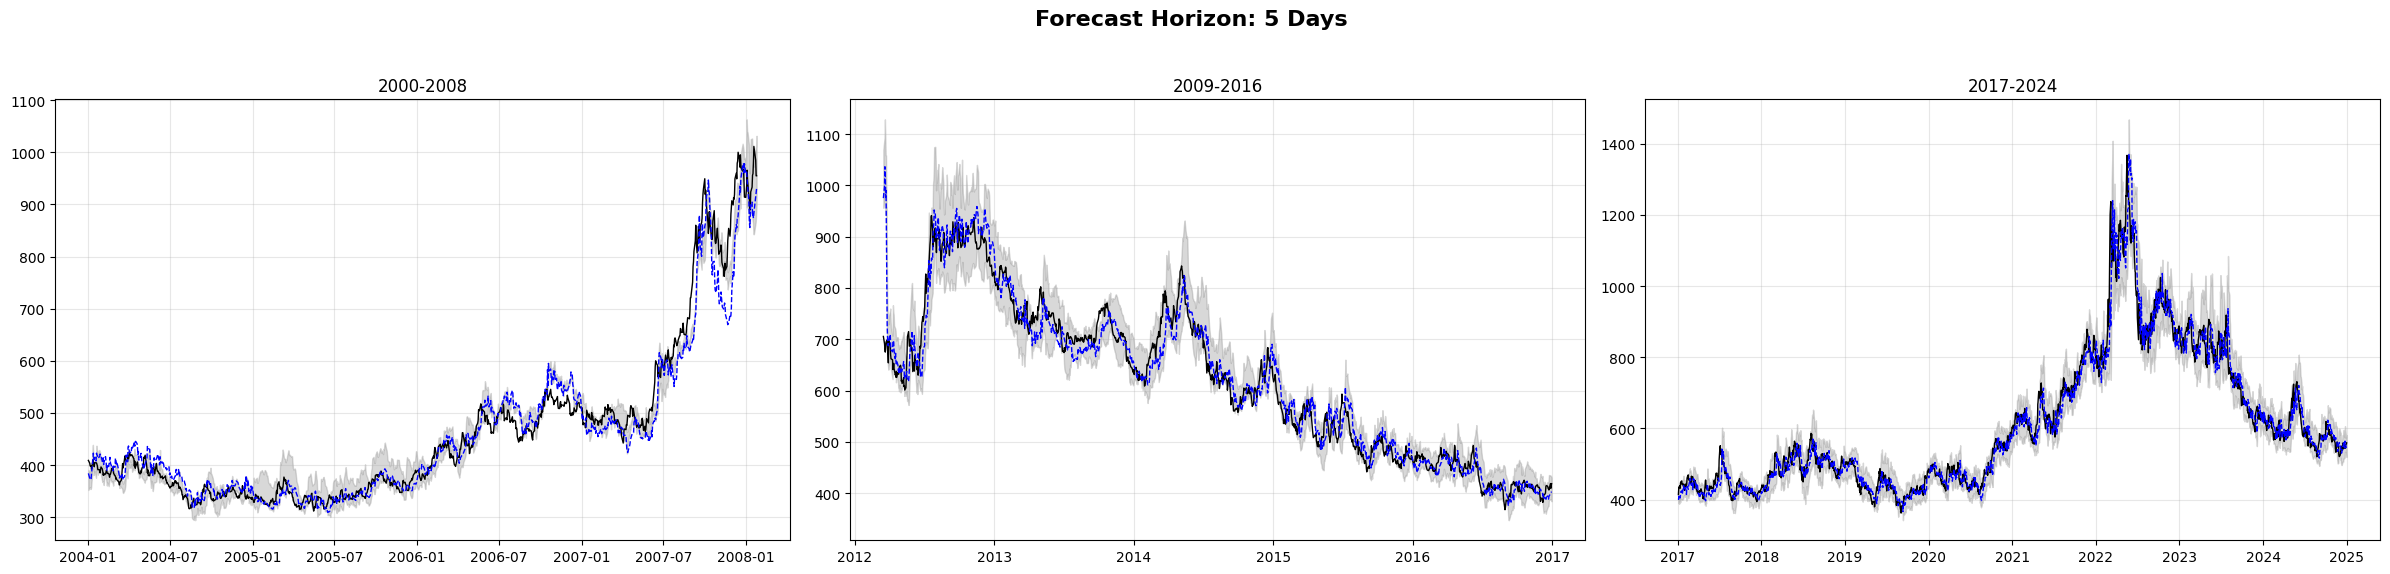

  -> Tuning Hyperparameters for Horizon 10...
     ! All trials failed. Using Safe Defaults.


H=10: Walking Forward:   0%|          | 0/21 [00:00<?, ?year/s]

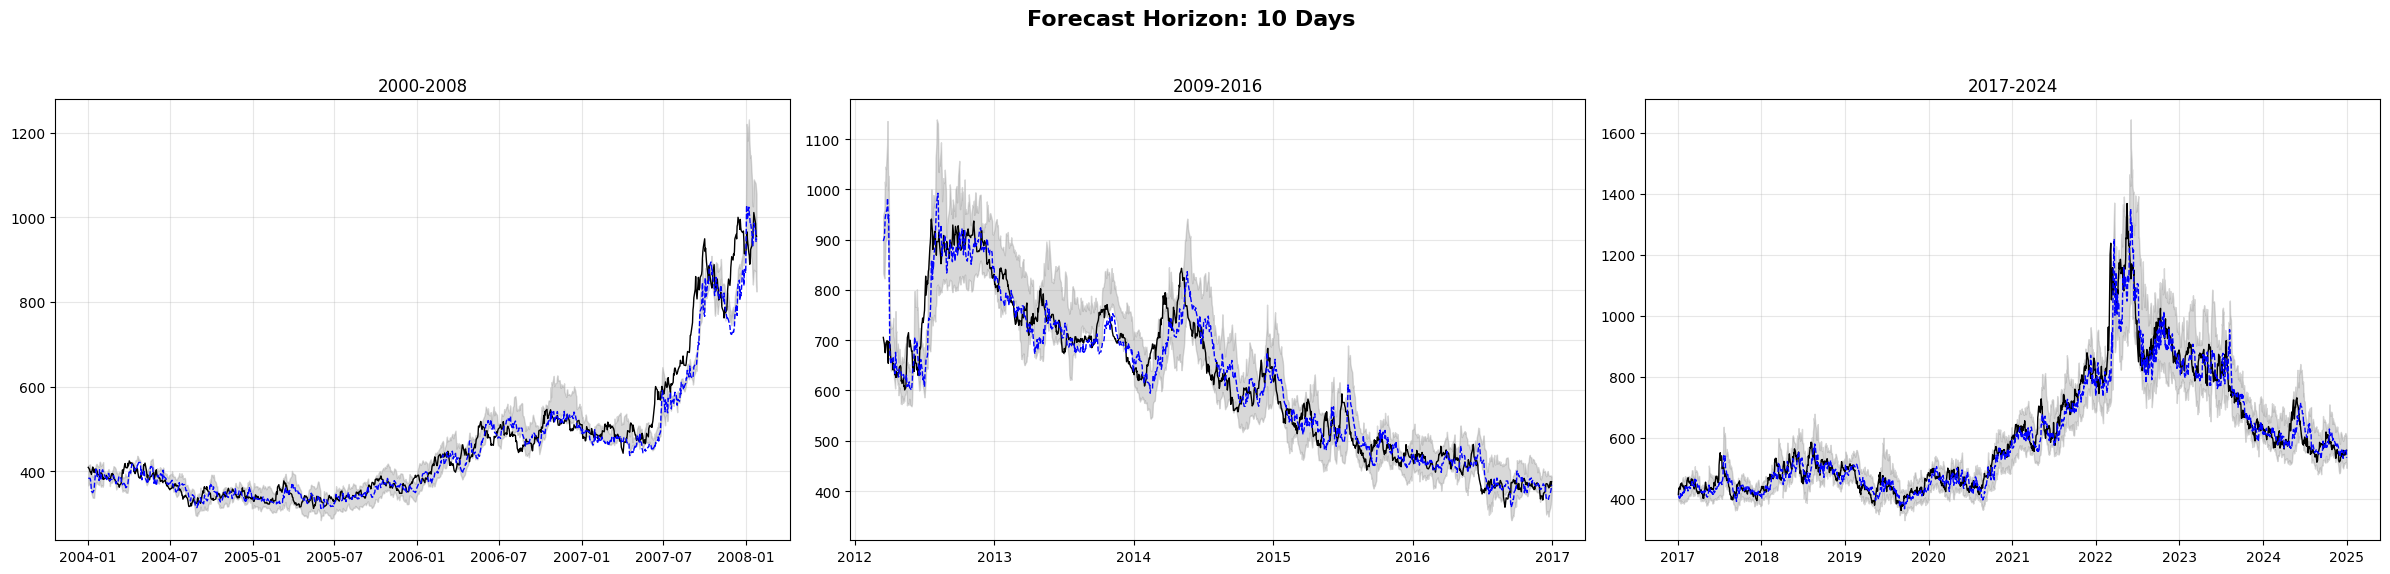

  -> Tuning Hyperparameters for Horizon 15...
     ! All trials failed. Using Safe Defaults.


H=15: Walking Forward:   0%|          | 0/21 [00:00<?, ?year/s]

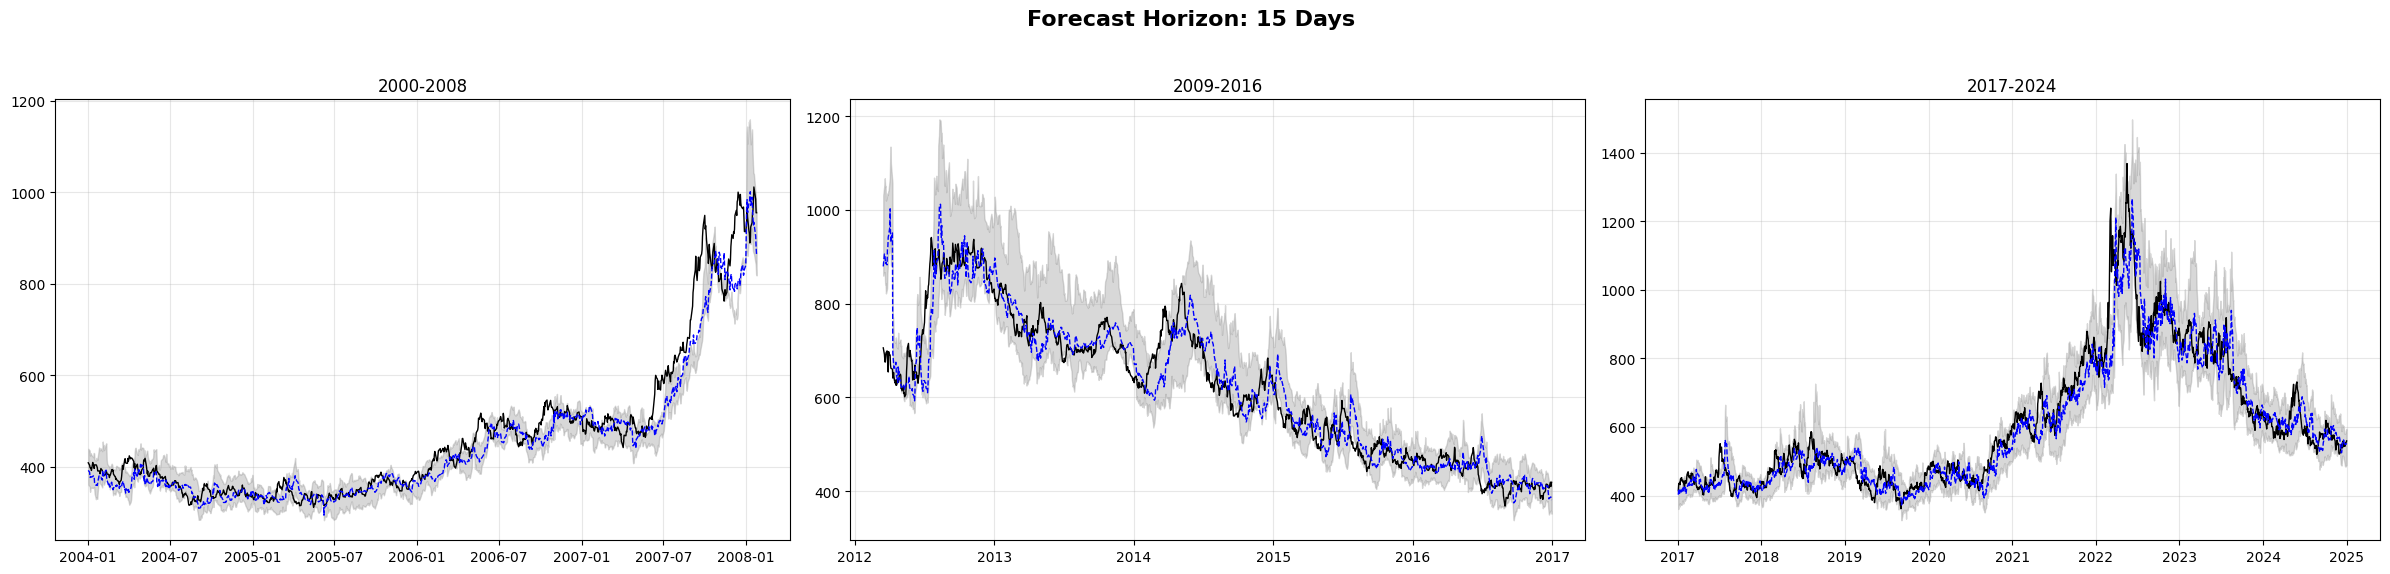

  -> Tuning Hyperparameters for Horizon 20...
     ! All trials failed. Using Safe Defaults.


H=20: Walking Forward:   0%|          | 0/21 [00:00<?, ?year/s]

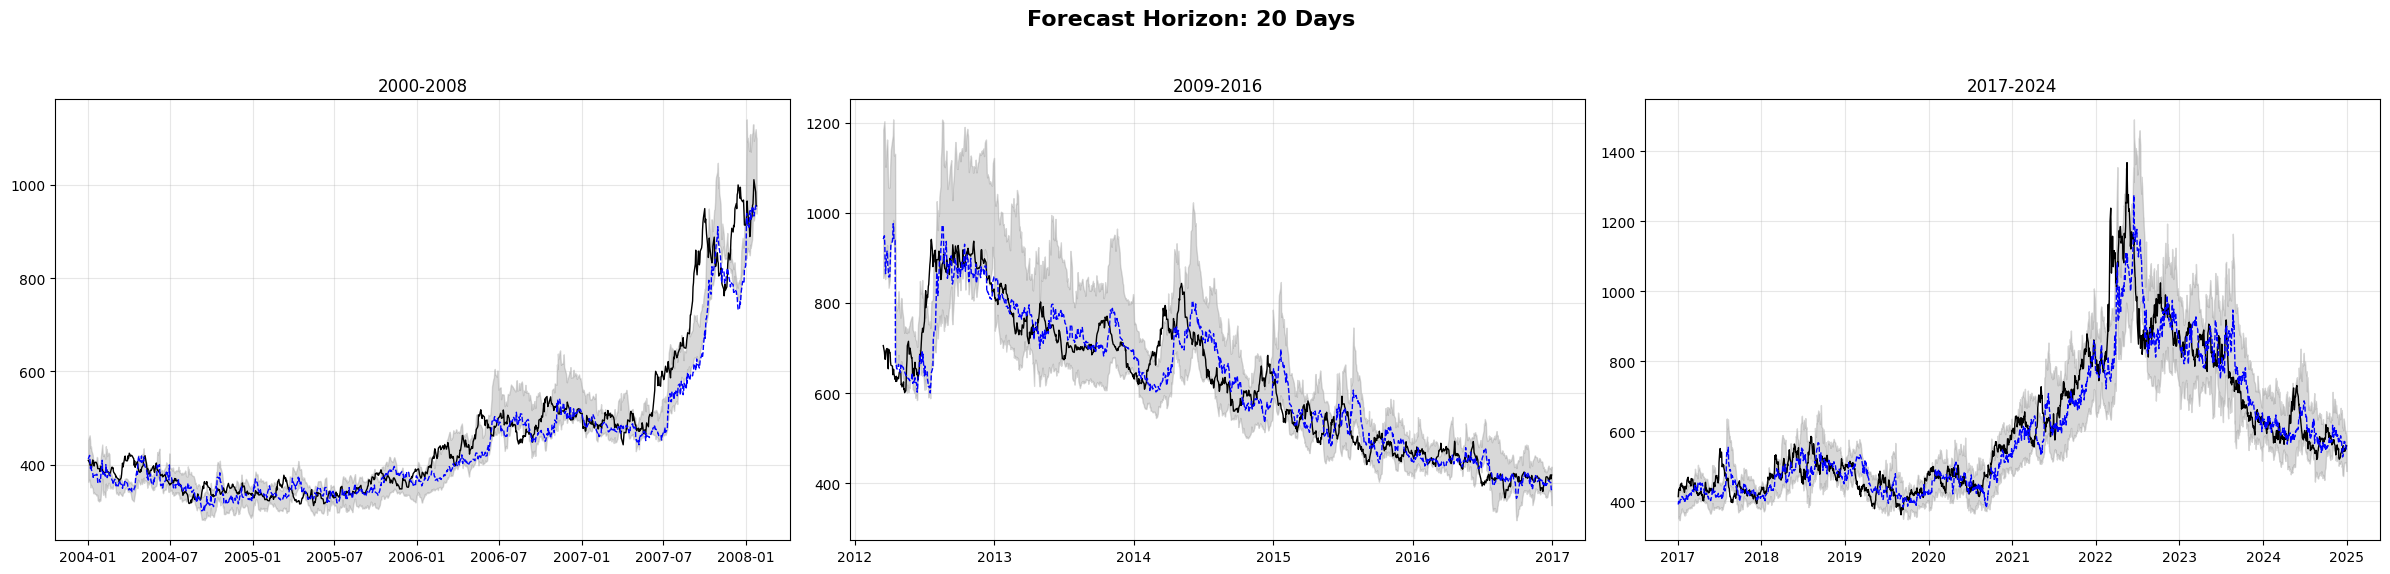

  -> Tuning Hyperparameters for Horizon 30...
     ! All trials failed. Using Safe Defaults.


H=30: Walking Forward:   0%|          | 0/21 [00:00<?, ?year/s]

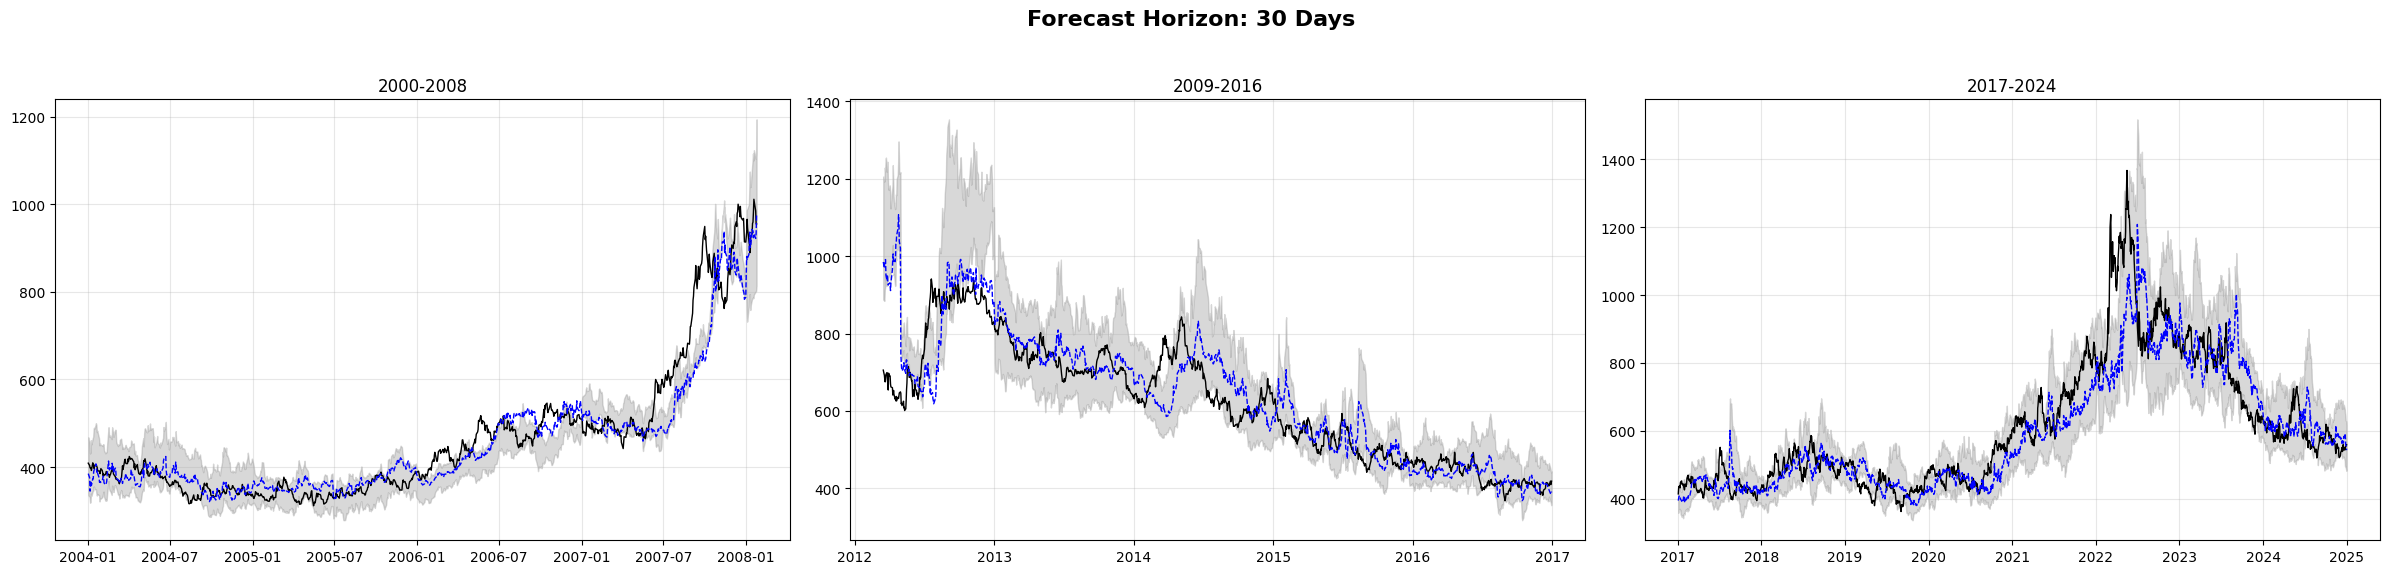


      FINAL RESEARCH METRICS (RETURN BASED)
|   Horizon | Period    |   RMSE_Ret |   MAE_Ret |   MAPE_Price |      DA |    PICP |
|----------:|:----------|-----------:|----------:|-------------:|--------:|--------:|
|         5 | GLOBAL    |  0.055076  | 0.0413988 |      4.12999 | 50.7407 | 77.1926 |
|         5 | 2000-2008 |  0.0636447 | 0.0500192 |      4.97077 | 48.4058 | 51.7874 |
|         5 | 2009-2016 |  0.0533039 | 0.0389989 |      3.9345  | 47.7612 | 80.9287 |
|         5 | 2017-2024 |  0.0512366 | 0.0384028 |      3.81467 | 53.7276 | 88.0219 |
|        10 | GLOBAL    |  0.0684246 | 0.0508784 |      5.02666 | 52.0574 | 77.9685 |
|        10 | 2000-2008 |  0.068979  | 0.0508187 |      4.94572 | 52.1739 | 57.2947 |
|        10 | 2009-2016 |  0.0678143 | 0.0495656 |      4.98253 | 51.99   | 77.529  |
|        10 | 2017-2024 |  0.0685024 | 0.051696  |      5.09475 | 52.0378 | 88.8668 |
|        15 | GLOBAL    |  0.0803688 | 0.0606139 |      5.98476 | 53.186  | 79.4028 |
|        

In [63]:
# Install required libraries
!pip install yfinance optuna

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import os
import optuna 
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tqdm.auto import tqdm

# ==========================================
# CONFIGURATION
# ==========================================
def get_input_path(filename):
    if os.path.exists(filename): return filename
    for root, _, files in os.walk('/kaggle/input'):
        if filename in files: return os.path.join(root, filename)
    return filename

MARKET_FILE = get_input_path('BIOFORGE_Market_Ready.csv') 
HORIZONS = [5, 10, 15, 20, 30] 
QUANTILES = [0.05, 0.5, 0.95]
START_TEST_YEAR = 2000 

ERAS = [
    ('2000-2008', '2000-01-01', '2008-12-31'),
    ('2009-2016', '2009-01-01', '2016-12-31'),
    ('2017-2024', '2017-01-01', '2024-12-31')
]

class QuantileBiLSTM(nn.Module):
    def __init__(self, num_features, hidden_dim=64, layers=2, dropout=0.3):
        super(QuantileBiLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size=num_features, hidden_size=hidden_dim, num_layers=layers, batch_first=True, bidirectional=True, dropout=dropout)
        self.head = nn.Sequential(
            nn.Linear(hidden_dim * 2, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 3) 
        )
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :])

class PinballLoss(nn.Module):
    def __init__(self, quantiles):
        super().__init__()
        self.quantiles = quantiles
    def forward(self, preds, target):
        loss = 0
        target_rep = target.repeat(1, len(self.quantiles))
        errors = target_rep - preds
        for i, q in enumerate(self.quantiles):
            loss += torch.max(q * errors[:, i], (q - 1) * errors[:, i]).mean()
        return loss

# ==========================================
# 2. HELPERS
# ==========================================
def prepare_sequences(df, seq_len, horizon):
    data = df.values.astype(np.float32)
    close_idx = df.columns.get_loc('Close')
    
    X, y, current_prices, dates = [], [], [], []
    df_dates = df.index
    
    for i in range(len(data) - seq_len - horizon):
        X.append(data[i : i+seq_len])
        
        # Prices
        price_current = data[i+seq_len-1, close_idx]
        price_future = data[i+seq_len+horizon : i+seq_len+horizon+1, close_idx]
        
        # Log Returns
        ret = np.log(price_future / (price_current + 1e-6))
        
        y.append(ret)
        current_prices.append(price_current)
        dates.append(df_dates[i+seq_len+horizon])
        
    return np.array(X), np.array(y), np.array(current_prices), np.array(dates)

def calculate_metrics(target_returns, p10, p50, p90, current_prices):
    if len(target_returns) == 0: return {}
    target_returns = target_returns.flatten()
    p50 = p50.flatten()
    current_prices = current_prices.flatten()

    rmse_ret = np.sqrt(mean_squared_error(target_returns, p50))
    mae_ret = mean_absolute_error(target_returns, p50)
    
    correct = np.sign(target_returns) == np.sign(p50)
    da = np.mean(correct) * 100
    
    hits = ((target_returns >= p10) & (target_returns <= p90))
    picp = np.mean(hits) * 100
    
    price_actual = current_prices * np.exp(target_returns)
    price_pred = current_prices * np.exp(p50)
    mape_price = np.mean(np.abs((price_actual - price_pred) / price_actual)) * 100
    
    return {'RMSE_Ret': rmse_ret, 'MAE_Ret': mae_ret, 'MAPE_Price': mape_price, 'DA': da, 'PICP': picp}

# ==========================================
# 3. EXECUTION
# ==========================================
def run_stage_D_returns():
    print("Loading Market Data...")
    if not os.path.exists(MARKET_FILE):
        print(f"Error: {MARKET_FILE} not found.")
        return

    df = pd.read_csv(MARKET_FILE, parse_dates=['Date'], index_col='Date').sort_index()
    
    train_end_date = df.index[0] + pd.DateOffset(years=15)
    base_df = df[df.index < train_end_date]
    mean, std = base_df.mean(), base_df.std()
    
    df_scaled = (df - mean) / std 
    # CLEAN DATA: Replace Infs with NaNs and then Drop
    df_scaled = df_scaled.replace([np.inf, -np.inf], np.nan).dropna()
    
    all_metrics = []
    
    horizon_pbar = tqdm(HORIZONS, desc="Processing Horizons", unit="horizon")
    
    for horizon in horizon_pbar:
        horizon_pbar.set_description(f"Processing Horizon: {horizon} Days")
        
        _, y_raw, curr_prices, dates_all = prepare_sequences(df, 60, horizon)
        X_scaled, _, _, _ = prepare_sequences(df_scaled, 60, horizon)
        
        # Check alignment after prep
        min_len = min(len(X_scaled), len(y_raw))
        X_scaled = X_scaled[:min_len]
        y_raw = y_raw[:min_len]
        dates_all = dates_all[:min_len]
        curr_prices = curr_prices[:min_len]
        
        dates_pd = pd.to_datetime(dates_all)
        years = dates_pd.year

        # --- OPTUNA TUNING ---
        print(f"  -> Tuning Hyperparameters for Horizon {horizon}...")
        
        def objective(trial):
            # 1. Reduce Learning Rate Range (High LR causes NaNs)
            lr = trial.suggest_float('lr', 1e-5, 1e-3, log=True) # Reduced Max LR
            h_dim = trial.suggest_categorical('hidden_dim', [32, 64, 128])
            n_layers = trial.suggest_int('layers', 1, 3)
            drp = trial.suggest_float('dropout', 0.1, 0.5)
            
            test_start_idx = np.where(years >= START_TEST_YEAR)[0][0]
            X_tune = X_scaled[:test_start_idx]
            y_tune = y_raw[:test_start_idx]
            
            split = int(len(X_tune) * 0.8)
            X_t = torch.tensor(X_tune[:split])
            y_t = torch.tensor(y_tune[:split])
            X_v = torch.tensor(X_tune[split:])
            y_v = torch.tensor(y_tune[split:])
            
            model = QuantileBiLSTM(X_t.shape[2], hidden_dim=h_dim, layers=n_layers, dropout=drp)
            optimizer = optim.Adam(model.parameters(), lr=lr)
            criterion = PinballLoss(QUANTILES)
            
            # --- CRASH PROTECTION BLOCK ---
            try:
                model.train()
                for _ in range(5): 
                    optimizer.zero_grad()
                    output = model(X_t)
                    loss = criterion(output, y_t)
                    
                    if torch.isnan(loss): raise ValueError("NaN Loss")
                    
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    optimizer.step()
                    
                model.eval()
                with torch.no_grad():
                    val_pred = model(X_v)
                    val_loss = criterion(val_pred, y_v).item()
                    if np.isnan(val_loss): raise ValueError("NaN Val Loss")
                    
                return val_loss
                
            except ValueError:
                # If training crashes, return Infinity so Optuna knows this config is bad
                return float('inf')

        optuna.logging.set_verbosity(optuna.logging.WARNING)
        study = optuna.create_study(direction='minimize')
        study.optimize(objective, n_trials=10) 
        
        # Fallback if ALL trials fail
        if len(study.trials) == 0 or study.best_value == float('inf'):
            print("     ! All trials failed. Using Safe Defaults.")
            best_params = {'hidden_dim': 64, 'layers': 1, 'dropout': 0.2, 'lr': 0.0001}
        else:
            best_params = study.best_params
            print(f"     Best Params for H={horizon}: {best_params}")

        # --- WALK FORWARD ---
        history_preds = []
        history_targets = []
        history_dates = []
        history_curr_prices = []
        
        test_years = sorted(np.unique(years[years >= START_TEST_YEAR]))
        year_pbar = tqdm(test_years, desc=f"H={horizon}: Walking Forward", leave=False, unit="year")
        
        for year in year_pbar:
            train_mask = (years < year)
            test_mask = (years == year)
            
            if np.sum(train_mask) < 500: continue
            if np.sum(test_mask) == 0: continue
            
            X_train = torch.tensor(X_scaled[train_mask])
            y_train = torch.tensor(y_raw[train_mask])
            X_test = torch.tensor(X_scaled[test_mask])
            
            model = QuantileBiLSTM(
                num_features=X_train.shape[2], 
                hidden_dim=best_params['hidden_dim'],
                layers=best_params['layers'],
                dropout=best_params['dropout']
            )
            
            optimizer = optim.Adam(model.parameters(), lr=best_params['lr'])
            criterion = PinballLoss(QUANTILES)
            
            train_ds = TensorDataset(X_train, y_train)
            loader = DataLoader(train_ds, batch_size=128, shuffle=True)
            
            model.train()
            for ep in range(15):
                for bx, by in loader:
                    optimizer.zero_grad()
                    output = model(bx)
                    loss = criterion(output, by)
                    if not torch.isnan(loss):
                        loss.backward()
                        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                        optimizer.step()
            
            model.eval()
            with torch.no_grad():
                preds = model(X_test).cpu().numpy()
            
            # Handle potential NaNs in prediction
            if np.isnan(preds).any():
                preds = np.nan_to_num(preds)
            
            history_preds.append(preds)
            history_targets.append(y_raw[test_mask])
            history_dates.append(dates_all[test_mask])
            history_curr_prices.append(curr_prices[test_mask])
        
        if not history_preds: continue
            
        full_preds_ret = np.vstack(history_preds)
        full_targets_ret = np.vstack(history_targets)
        full_dates = np.concatenate(history_dates)
        full_curr = np.concatenate(history_curr_prices)
        
        full_curr_expanded = full_curr[:, np.newaxis]
        price_actual = full_curr * np.exp(full_targets_ret.flatten())
        price_pred_p10 = full_curr * np.exp(full_preds_ret[:, 0])
        price_pred_p50 = full_curr * np.exp(full_preds_ret[:, 1])
        price_pred_p90 = full_curr * np.exp(full_preds_ret[:, 2])
        
        df_res = pd.DataFrame({
            'Actual_Price': price_actual,
            'P50_Price': price_pred_p50,
            'P10_Price': price_pred_p10,
            'P90_Price': price_pred_p90,
            'Actual_Ret': full_targets_ret.flatten(),
            'P50_Ret': full_preds_ret[:, 1],
            'P10_Ret': full_preds_ret[:, 0],
            'P90_Ret': full_preds_ret[:, 2],
            'Current': full_curr
        }, index=full_dates)
        
        m_global = calculate_metrics(
            df_res['Actual_Ret'].values, df_res['P10_Ret'].values, df_res['P50_Ret'].values, df_res['P90_Ret'].values, df_res['Current'].values
        )
        m_global['Horizon'] = horizon
        m_global['Period'] = 'GLOBAL'
        all_metrics.append(m_global)
        
        fig, axes = plt.subplots(1, 3, figsize=(24, 6))
        fig.suptitle(f'Forecast Horizon: {horizon} Days ', fontsize=16, fontweight='bold')
        
        for idx, (era_name, start, end) in enumerate(ERAS):
            mask = (df_res.index >= start) & (df_res.index <= end)
            chunk = df_res[mask]
            ax = axes[idx]
            if len(chunk) > 0:
                ax.plot(chunk.index, chunk['Actual_Price'], 'k-', lw=1, label='Actual')
                ax.plot(chunk.index, chunk['P50_Price'], 'b--', lw=1, label='Pred')
                ax.fill_between(chunk.index, chunk['P10_Price'], chunk['P90_Price'], color='gray', alpha=0.3)
                ax.set_title(era_name)
                ax.grid(True, alpha=0.3)
                
                m_era = calculate_metrics(
                    chunk['Actual_Ret'].values, chunk['P10_Ret'].values, chunk['P50_Ret'].values, chunk['P90_Ret'].values, chunk['Current'].values
                )
                m_era['Horizon'] = horizon
                m_era['Period'] = era_name
                all_metrics.append(m_era)
            else:
                ax.text(0.5, 0.5, "No Data", ha='center')
        
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.savefig(f'BioForge_H{horizon}_Returns.png')
        plt.show()

    res_df = pd.DataFrame(all_metrics)
    cols = ['Horizon', 'Period', 'RMSE_Ret', 'MAE_Ret', 'MAPE_Price', 'DA', 'PICP']
    res_df = res_df[cols]
    
    print("\n" + "="*40)
    print("      FINAL RESEARCH METRICS (RETURN BASED)")
    print("="*40)
    print(res_df.to_markdown(index=False))
    res_df.to_csv('BioForge_Metrics_Returns.csv', index=False)

if __name__ == "__main__":
    run_stage_D_returns()